# Support Vector Machine (SVM)

Accuracy: 100.00

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

CV scores: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Mean CV accuracy: 0.9666666666666666


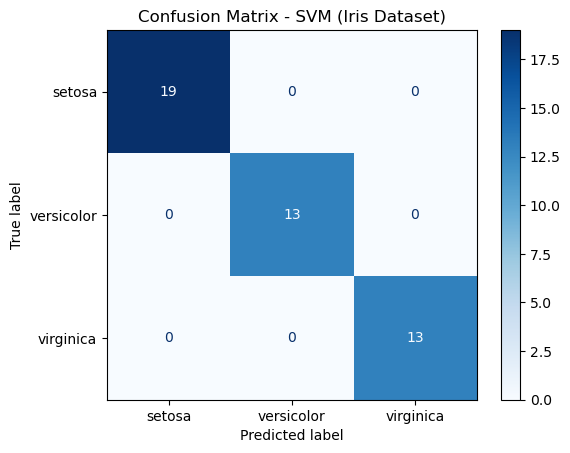

In [7]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ------------------------------------------------------------------------------
# Load the Iris dataset
iris = datasets.load_iris()
# ------------------------------------------------------------------------------
# Split the data
X = iris.data 
Y = iris.target
# ------------------------------------------------------------------------------
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
# Create an SVM model (e.g., using an RBF kernel)
svm_model = SVC(kernel='rbf', random_state=42)
# Train the SVM model
svm_model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = svm_model.predict(X_test)
# ------------------------------------------------------------------------------
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}")
print("\nClassification Report")
print(classification_report(y_test, y_pred))
#---------------------------------------------
scores = cross_val_score(svm_model, X, Y, cv=5)
print("CV scores:", scores)
print("Mean CV accuracy:", scores.mean())
#-------------------------------------------
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM (Iris Dataset)")
plt.show()

**This code trains a linear SVM classifier on the first two features of the Iris dataset and visualizes the decision boundaries and data points.**

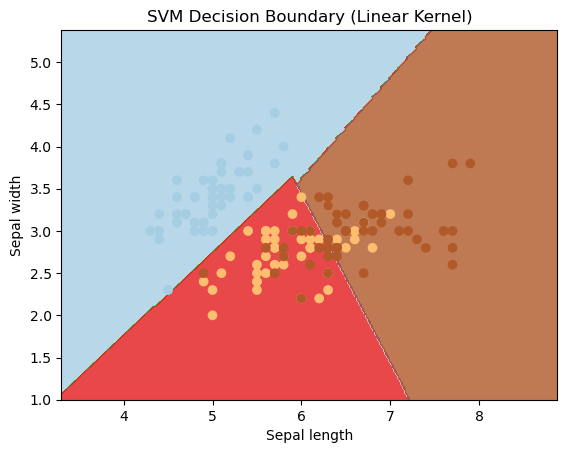

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

# Load iris dataset
iris = datasets.load_iris()

# Take only first two features
X = iris.data[:, :2]
y = iris.target

# Create SVM model
svc = svm.SVC(kernel='linear', C=1.0)
svc.fit(X, y)

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

h = 0.02

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict for each point in mesh
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

# Plot training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("SVM Decision Boundary (Linear Kernel)")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.show()


**SVM On Stock Prices**

            Date  Prev Close     Open     High      Low    Close     VWAP    Volume
0       1/1/1996      204.65   205.00   206.10   203.65   205.75   205.26   3717450
1       1/2/1996      205.75   205.25   206.25   202.65   204.15   204.13   6024650
...          ...         ...      ...      ...      ...      ...      ...       ...
6203  11/26/2020     1947.80  1953.05  1965.00  1930.05  1952.60  1946.67  11924527
6204  11/27/2020     1952.60  1940.50  1956.10  1921.40  1929.80  1935.45  21845931
-----------------------------------------------------------------------
            Prev Close     Open     High      Low    Close     VWAP    Volume
Date                                                                         
1996-01-01      204.65   205.00   206.10   203.65   205.75   205.26   3717450
1996-01-02      205.75   205.25   206.25   202.65   204.15   204.13   6024650
...                ...      ...      ...      ...      ...      ...       ...
2020-11-26     1947.80  1953.05  1

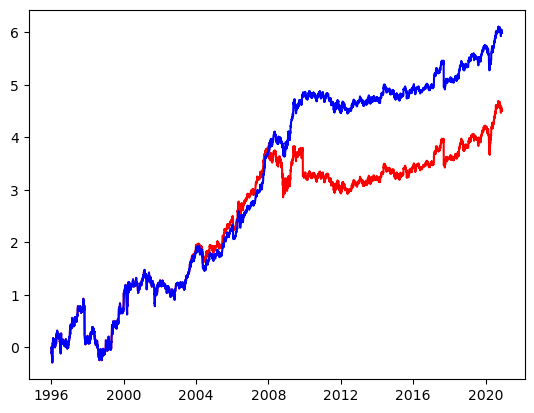

In [38]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ------------------------------------------------------------------------------
df = pd.read_csv('Stock.csv')
print(df.to_string(max_rows=5))
# ------------------------------------------------------------------------------
df.index = pd.to_datetime(df['Date'])
df = df.drop(['Date'], axis='columns')
print("-----------------------------------------------------------------------")
print(df.to_string(max_rows=5))
# ------------------------------------------------------------------------------
# Create predictor variables
df['Open-Close'] = df.Open - df.Close
df['High-Low'] = df.High - df.Low
newdf = df[['Open-Close', 'High-Low']]
print("-----------------------------------------------------------------------")
print(newdf.to_string(max_rows=5))
# ------------------------------------------------------------------------------

# Target variables
target = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
# ------------------------------------------------------------------------------
split_percentage = 0.8
split = int(split_percentage*len(df))
# Train data set
X_train = newdf[:split]
y_train = target[:split]
# Test data set
X_test = newdf[split:]
y_test = target[split:]
# ------------------------------------------------------------------------------
# Support vector classifier
model = SVC(kernel='rbf', random_state=42)
model.fit(X_train, y_train)
# ------------------------------------------------------------------------------
df['Predicted_Signal'] = model.predict(newdf)
print("-----------------------------------------------------------------------")
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("-----------------------------------------------------------------------")
print(df['Predicted_Signal'].to_string(max_rows=5))
df['Return'] = df.Close.pct_change()
df['Strategy_Return'] = df.Return * df.Predicted_Signal.shift(1)
df['Cum_Ret'] = df['Return'].cumsum() 
df['Cum_Strategy'] = df['Strategy_Return'].cumsum()
plt.plot(df['Cum_Ret'],color='red')
plt.plot(df['Cum_Strategy'],color='blue')
print(df.to_string())

**breast cancer**

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter  worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension  target
0         17.990         10.38          122.80     1001.0          0.11840           0.27760        0.300100             0.147100         0.2419                 0.07871        1.0950         0.9053           8.5890     153.400          0.006399           0.049040         0.053730              0.015870        0.030030                 0.006193        25.380          17.33           184.60      2019.0           0.16220            0.66560         0.711900              0.26

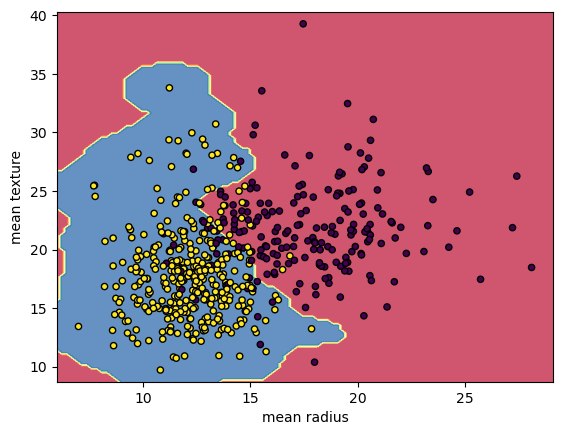

In [39]:
# Load the important packages
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
# ---------------------------------------------------------------------------
# Load the datasets
cancer = load_breast_cancer()
# Convert the dataset into a DataFrame for better visualization
cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
# Add the target column to the DataFrame (labels for each sample)
cancer_df['target'] = cancer.target
# Display the first few rows of the DataFrame
print(cancer_df.to_string())
print("Describe -----------------------------------------------------------")
# Statistical summary of the dataset
print(cancer_df.describe())
# ---------------------------------------------------------------------------
X = cancer.data[:, :2]
y = cancer.target
# ---------------------------------------------------------------------------
svm = SVC(kernel="rbf", gamma=0.5, C=1.0) # Build the model
svm.fit(X, y) # Trained the model
# ---------------------------------------------------------------------------
# Plot Decision Boundary
DecisionBoundaryDisplay.from_estimator(
        svm,
        X,
        response_method="predict",
        cmap=plt.cm.Spectral,
        alpha=0.8,
        xlabel=cancer.feature_names[0],
        ylabel=cancer.feature_names[1])
# ---------------------------------------------------------------------------
# Scatter plot
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors="k")
plt.show()